## Entrenamiento final.

In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import json

In [2]:
archivo = "CSVs/parámetros_columnas.json"

with open(archivo, "r") as f:
    datos = json.load(f)
    
mejores_parametros = datos["mejores_parametros"]
x_columnas = datos["x_columnas"]
y_columnas = datos["y_columnas"]

In [3]:
train_viajeros = pd.read_csv("CSVs/train_viajeros.csv")
test_viajeros = pd.read_csv("CSVs/test_viajeros.csv")
prediccion_viajeros = pd.read_csv("CSVs/prediccion_viajeros.csv")
df_verano_viajeros = pd.read_csv("CSVs/verano_viajeros.csv")

In [4]:
categoricas_viajeros = [x_columnas.index("Provincias")]

In [5]:
x_train_viajeros = train_viajeros[x_columnas]
y_train_viajeros = train_viajeros[y_columnas]

x_test_viajeros = test_viajeros[x_columnas]
y_test_viajeros = test_viajeros[y_columnas]

## CatBoost

### Evaluación final sobre test.

In [6]:
modelo_test = CatBoostRegressor(
    iterations=1500,
    learning_rate=mejores_parametros["learning_rate"],
    depth =mejores_parametros["depth"] ,
    l2_leaf_reg=mejores_parametros["l2"] ,
    loss_function="RMSE",
    random_seed=42,
    early_stopping_rounds=100,
    verbose=0
)

modelo_test.fit(x_train_viajeros, y_train_viajeros, cat_features=categoricas_viajeros)

prediccion_log = modelo_test.predict(x_test_viajeros)

turistas_pasados = test_viajeros["Turistas_pasados"]
turistas_reales = test_viajeros["Turistas_totales"]

# Predicción CatBoost
ratio = np.exp(prediccion_log)
turistas_p = turistas_pasados * ratio

#Predicció Naive
prediccion_naive = turistas_pasados.fillna(0)


mae_viajeros = mean_absolute_error(turistas_reales, turistas_p)
rmse_viajeros = np.sqrt(mean_squared_error(turistas_reales, turistas_p))

mae_naive = mean_absolute_error(turistas_reales, prediccion_naive)
rmse_naive = np.sqrt(mean_squared_error(turistas_reales, prediccion_naive))

mape_viajeros = np.mean(np.abs(turistas_reales - turistas_p) / (turistas_reales + 1e-6))
precision_viajeros = 100 * (1-mape_viajeros)

mape_naive = np.mean(np.abs(turistas_reales - prediccion_naive) / (turistas_reales + 1e-6))
precision_naive = 100 * (1-mape_naive)

print(f"CATBOOST--- MAE: {mae_viajeros:.3f}, RMSE: {rmse_viajeros:.3f}, PRECISIÓN: {precision_viajeros:.2f}%")
print(f"NAIVE--- MAE: {mae_naive:.3f}, RMSE: {rmse_naive:.3f}, PRECISIÓN: {precision_naive:.2f}%")
      
if rmse_viajeros < rmse_naive:
    diferencia = rmse_naive - rmse_viajeros
    print(f"El modelo CatBoost es mejor.")
else:
    print(f"El modelo CatBoost no super al Naive.")

CATBOOST--- MAE: 4900.895, RMSE: 9652.046, PRECISIÓN: 91.37%
NAIVE--- MAE: 11675.699, RMSE: 24424.254, PRECISIÓN: 81.91%
El modelo CatBoost es mejor.


### Entrenamiento final del modelo.

Se prepara x, y.

In [7]:
df_train_final_viajeros = pd.concat([train_viajeros, test_viajeros])

x_train_final_viajeros = df_train_final_viajeros[x_columnas]
y_train_final_viajeros = df_train_final_viajeros[y_columnas]

Entrenamiento final del modelo.

In [8]:
modelo_final_viajeros = CatBoostRegressor(
        iterations=1500,
        learning_rate=mejores_parametros["learning_rate"],
        depth=mejores_parametros["depth"],
        l2_leaf_reg=mejores_parametros["l2"],
        loss_function="RMSE",
        random_seed=42,
        early_stopping_rounds=100,
        verbose=200
    )

modelo_final_viajeros.fit(x_train_final_viajeros, y_train_final_viajeros, cat_features=categoricas_viajeros)

0:	learn: 0.2489921	total: 39.6ms	remaining: 59.3s
200:	learn: 0.1275339	total: 5.78s	remaining: 37.3s
400:	learn: 0.0959997	total: 12.5s	remaining: 34.2s
600:	learn: 0.0770693	total: 18.7s	remaining: 28s
800:	learn: 0.0646586	total: 24.7s	remaining: 21.6s
1000:	learn: 0.0563905	total: 30.5s	remaining: 15.2s
1200:	learn: 0.0499864	total: 36.6s	remaining: 9.11s
1400:	learn: 0.0446497	total: 42.4s	remaining: 3s
1499:	learn: 0.0425742	total: 45.4s	remaining: 0us


In [9]:
df_verano_viajeros = df_verano_viajeros.sort_values(["Provincias", "Año", "Mes"]).reset_index(drop=True)

meses_verano = [6,7,8]

for mes in meses_verano:
    grupo = df_verano_viajeros.groupby("Provincias")["Turistas_totales"]

    df_verano_viajeros["Turistas_pasados"] = grupo.shift(1)

    for lag in [1,2,3,4]:
        df_verano_viajeros[f"lag_{lag}"] = grupo.shift(lag)

        df_verano_viajeros[f"log_lag_{lag}"] = np.log1p(df_verano_viajeros[f"lag_{lag}"].fillna(0))

    df_verano_viajeros["media_lag_2"] = (df_verano_viajeros["log_lag_1"] + df_verano_viajeros["log_lag_2"]) / 2

    df_verano_viajeros["media_lag_3"] = (df_verano_viajeros["log_lag_1"] +
                                    df_verano_viajeros["log_lag_2"] +
                                    df_verano_viajeros["log_lag_3"]) / 3

    df_verano_viajeros["tendencia_corta"] = df_verano_viajeros["log_lag_1"] - df_verano_viajeros["log_lag_2"]

    mask_mes = ((df_verano_viajeros["Año"] == 2026) & (df_verano_viajeros["Mes"] == mes))

    prediccion_log_ratio = modelo_final_viajeros.predict(df_verano_viajeros.loc[mask_mes, x_columnas])

    ratio_final = np.exp(prediccion_log_ratio)

    valor = (df_verano_viajeros.loc[mask_mes, "Turistas_pasados"] * ratio_final)

    df_verano_viajeros.loc[mask_mes, "Turistas_totales"] = valor


Predicción final.

In [10]:
df_verano_2026 = df_verano_viajeros[df_verano_viajeros["Año"] == 2026].copy()

df_verano_2026["Predicciones"] = df_verano_2026["Turistas_totales"]

prediccion_verano_viajeros = (df_verano_2026.groupby("Provincias")["Predicciones"].sum().reset_index().sort_values(by="Predicciones", ascending=False))

prediccion_verano_viajeros


,Provincias,Predicciones
24,Illes Balears,5.353107e+06
7,Barcelona,3.396226e+06
31,Madrid,2.012973e+06
27,Las Palmas,1.323628e+06
34,Málaga,1.305844e+06
19,Girona,1.157713e+06
2,Alicante/Alacant,8.516740e+05
40,Santa Cruz de Tenerife,8.309112e+05
44,Tarragona,6.896069e+05
42,Sevilla,5.493564e+05


Visualización.

In [11]:
df_tabla = prediccion_verano_viajeros.copy()

df_tabla["Predicciones"] = df_tabla["Predicciones"].apply(
    lambda x: f"{x:,.0f}".replace(",", ".")
)

division = int(np.ceil(len(df_tabla)/4))
columna_1 = df_tabla.iloc[:division].reset_index(drop=True)
columna_2 = df_tabla.iloc[division:2*division].reset_index(drop=True)
columna_3 = df_tabla.iloc[2*division:3*division].reset_index(drop=True)
columna_4 = df_tabla.iloc[3*division:].reset_index(drop=True)

df_tabla_final = pd.concat([columna_1, columna_2, columna_3, columna_4], axis=1)
df_tabla_final.columns = ["Provincias", "Turistas", "Provincias", "Turistas", "Provincias", "Turistas", "Provincias", "Turistas"]

df_tabla_final 

,Provincias,Turistas,Provincias,Turistas,Provincias,Turistas,Provincias,Turistas
0,Illes Balears,5.353.107,Bizkaia,285.842,Córdoba,110.905,Jaén,18.907
1,Barcelona,3.396.226,Cádiz,278.698,Lugo,78.576,Ciudad Real,18.746
2,Madrid,2.012.973,A Coruña,262.439,Castellón/Castelló,78.274,Palencia,18.629
3,Las Palmas,1.323.628,Pontevedra,215.816,Huesca,71.451,Ourense,15.827
4,Málaga,1.305.844,Asturias,168.153,León,70.210,Ávila,15.546
5,Girona,1.157.713,Burgos,147.319,Lleida,65.344,Teruel,15.521
6,Alicante/Alacant,851.674,Huelva,144.012,Araba/Álava,60.981,Albacete,13.722
7,Santa Cruz de Tenerife,830.911,Murcia,136.076,Toledo,60.315,Guadalajara,10.026
8,Tarragona,689.607,Zaragoza,132.212,La Rioja,58.888,Cuenca,9.774
9,Sevilla,549.356,Salamanca,131.902,Badajoz,58.608,Zamora,9.080


In [13]:
df_tabla_final.to_excel("../graficos/tabla_catboost_2.xlsx", index=False)

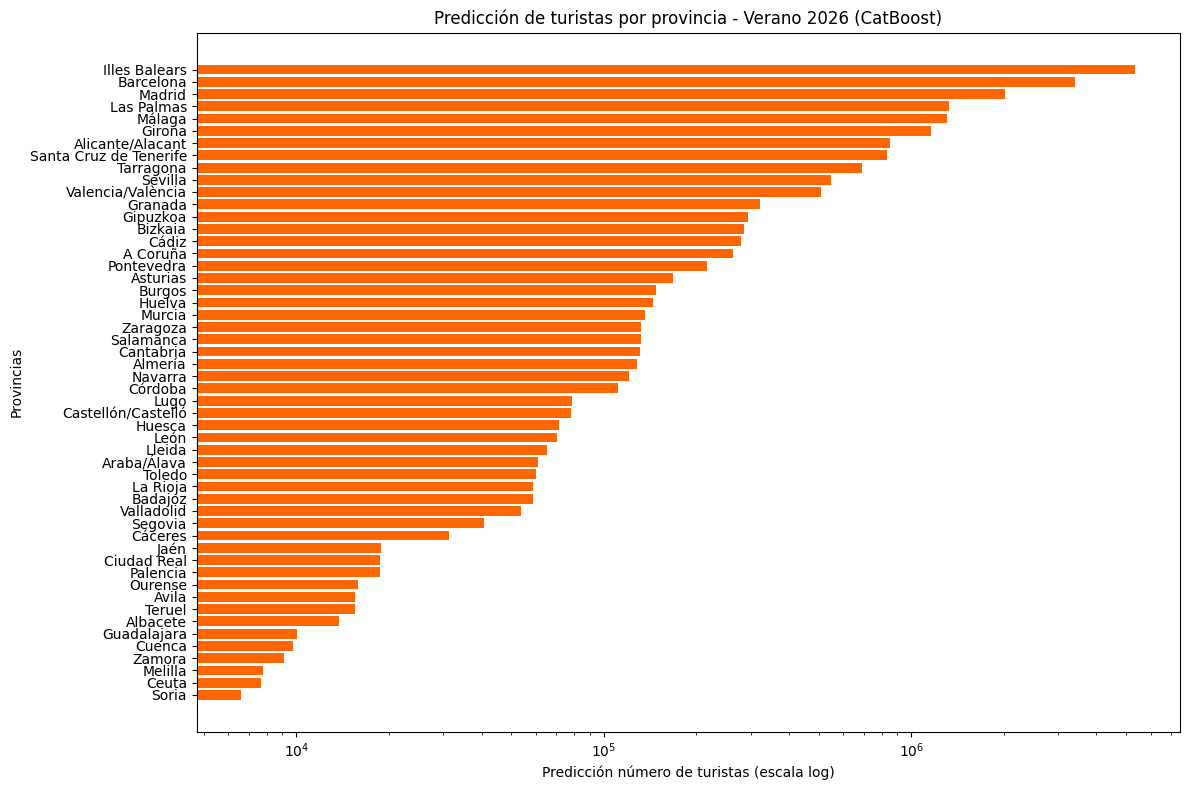

In [ ]:
plt.figure(figsize=(12,8))
plt.barh(prediccion_verano_viajeros["Provincias"], prediccion_verano_viajeros["Predicciones"], color= "#ff6600")
plt.gca().invert_yaxis()
plt.xscale("log")
plt.xlabel("Predicción número de turistas (escala log)")
plt.ylabel("Provincias")
plt.title("Predicción de turistas por provincia - Verano 2026 (CatBoost)")
plt.tight_layout()
plt.show()